# CH03_05. 컨텍스트 오프로딩: 로컬 파일 시스템

## 1. 환경 설정

In [2]:
import os
from dotenv import load_dotenv


# 환경 변수 확인
print("=== LangSmith 설정 상태 ===")
print(f"LANGSMITH_API_KEY: {'설정됨' if os.getenv('LANGSMITH_API_KEY') else '미설정 ⚠️'}")
print(f"LANGSMITH_TRACING: {os.getenv('LANGSMITH_TRACING', '미설정')}")
print(f"LANGSMITH_PROJECT: {os.getenv('LANGSMITH_PROJECT', '미설정 (default 사용)')}")
print(f"OPENAI_API_KEY: {'설정됨' if os.getenv('OPENAI_API_KEY') else '미설정 ⚠️'}")

# 프로젝트 이름 설정 (선택)
os.environ["LANGSMITH_PROJECT"] = "fc-agent-bible-appendix"

print("Tracing이 활성화되었습니다.")

=== LangSmith 설정 상태 ===
LANGSMITH_API_KEY: 설정됨
LANGSMITH_TRACING: 미설정
LANGSMITH_PROJECT: fc-agent-bible-appendix
OPENAI_API_KEY: 설정됨
Tracing이 활성화되었습니다.


In [3]:
from pathlib import Path
from datetime import datetime
import warnings
from exa_py import Exa

warnings.filterwarnings("ignore")

# EXA API 클라이언트 초기화
exa_client = Exa(api_key=os.environ["EXA_API_KEY"])

# 🗂️ 워크스페이스 디렉토리 설정
# 에이전트가 파일을 읽고 쓸 실제 로컬 디렉토리
WORKSPACE_DIR = Path("./agent_workspace")
WORKSPACE_DIR.mkdir(exist_ok=True)

def get_today_str() -> str:
    return datetime.now().strftime("%Y-%m-%d")

print(f"✅ 환경 설정 완료")
print(f"📁 워크스페이스 디렉토리: {WORKSPACE_DIR.absolute()}")
print(f"🔍 EXA API 클라이언트 초기화 완료")

✅ 환경 설정 완료
📁 워크스페이스 디렉토리: c:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project\agent_workspace
🔍 EXA API 클라이언트 초기화 완료


## 2. 상태 정의

In [4]:
from typing import TypedDict, Annotated
from typing_extensions import NotRequired
from langgraph.graph.message import add_messages

# Todo 아이템 정의
class Todo(TypedDict):
    content: str
    status: str

# 에이전트 상태 정의 (파일은 로컬 디스크에 저장)
class AgentState(TypedDict):
    """에이전트 상태 스키마
    
    Attributes:
        messages: 대화 기록 (add_messages 리듀서 사용)
        todos: 할 일 목록
    
    Note:
        파일은 WORKSPACE_DIR에 실제로 저장되므로 상태에 포함하지 않음
    """
    messages: Annotated[list, add_messages]
    todos: NotRequired[list[Todo]]

print("✅ 상태 스키마가 정의되었습니다.")
print(f"   - messages: 대화 기록")
print(f"   - todos: 할 일 목록")
print(f"   - 파일: {WORKSPACE_DIR} (로컬 디스크)")

✅ 상태 스키마가 정의되었습니다.
   - messages: 대화 기록
   - todos: 할 일 목록
   - 파일: agent_workspace (로컬 디스크)


## 3. 파일 도구 정의

### 3.1 ls 도구
가상 파일 시스템의 모든 파일 목록을 반환합니다.

In [5]:
from langchain_core.messages import ToolMessage
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

# ls 도구 설명
LS_DESCRIPTION = """
워크스페이스 디렉토리의 모든 파일과 폴더를 나열합니다.

에이전트가 작업할 수 있는 파일 목록을 확인합니다.
다른 파일 작업 전에 파일 구조를 파악하는 데 사용하세요.

파라미터 없이 ls()를 호출하면 모든 파일을 볼 수 있습니다.
"""

@tool(description=LS_DESCRIPTION)
def ls(path: str = ".") -> str:
    """워크스페이스 디렉토리의 파일을 나열합니다.
    
    Args:
        path: 조회할 상대 경로 (기본값: 워크스페이스 루트)
    
    Returns:
        파일 목록 또는 오류 메시지
    """
    target_dir = WORKSPACE_DIR / path
    
    if not target_dir.exists():
        return f"오류: 경로 '{path}'가 존재하지 않습니다."
    
    if not target_dir.is_dir():
        return f"오류: '{path}'는 디렉토리가 아닙니다."
    
    items = []
    for item in sorted(target_dir.iterdir()):
        if item.is_dir():
            items.append(f"📁 {item.name}/")
        else:
            size = item.stat().st_size
            items.append(f"📄 {item.name} ({size} bytes)")
    
    if not items:
        return "(파일이 없습니다)"
    
    return "\n".join(items)

print("✅ ls 도구가 정의되었습니다.")
print(f"   - 대상 디렉토리: {WORKSPACE_DIR.absolute()}")

✅ ls 도구가 정의되었습니다.
   - 대상 디렉토리: c:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project\agent_workspace


### 3.2 read_file 도구
파일 내용을 읽습니다. 큰 파일을 위한 페이지네이션을 지원합니다.

In [6]:
# read_file 도구 설명
READ_FILE_DESCRIPTION = """
워크스페이스에서 파일 내용을 읽습니다. 페이지네이션을 지원합니다.

이 도구는 줄 번호와 함께 파일 내용을 반환합니다(cat -n과 유사).
컨텍스트 오버플로우를 방지하기 위해 큰 파일을 청크로 읽을 수 있습니다.

파라미터:
- file_path (필수): 읽을 파일 경로 (워크스페이스 기준 상대 경로)
- offset (선택, 기본값=0): 읽기 시작할 줄 번호
- limit (선택, 기본값=2000): 읽을 최대 줄 수

편집하기 전에 항상 먼저 파일을 읽어 기존 내용을 파악하세요.
"""

@tool(description=READ_FILE_DESCRIPTION, parse_docstring=True)
def read_file(
    file_path: str,
    offset: int = 0,
    limit: int = 2000,
) -> str:
    """워크스페이스에서 파일 내용을 읽습니다.

    Args:
        file_path: 읽을 파일 경로 (워크스페이스 기준 상대 경로)
        offset: 읽기 시작할 줄 번호 (기본값: 0)
        limit: 읽을 최대 줄 수 (기본값: 2000)

    Returns:
        줄 번호가 포함된 파일 내용, 또는 오류 메시지
    """
    target_file = WORKSPACE_DIR / file_path
    
    # 보안: 워크스페이스 외부 접근 방지
    try:
        target_file = target_file.resolve()
        if not str(target_file).startswith(str(WORKSPACE_DIR.resolve())):
            return f"오류: 워크스페이스 외부 접근 불가"
    except Exception:
        return f"오류: 잘못된 경로 '{file_path}'"
    
    if not target_file.exists():
        return f"오류: 파일 '{file_path}'을(를) 찾을 수 없습니다."
    
    if not target_file.is_file():
        return f"오류: '{file_path}'는 파일이 아닙니다."

    try:
        content = target_file.read_text(encoding="utf-8")
    except Exception as e:
        return f"오류: 파일 읽기 실패 - {e}"
    
    if not content:
        return "참고: 파일이 존재하지만 내용이 비어 있습니다."

    lines = content.splitlines()
    start_idx = offset
    end_idx = min(start_idx + limit, len(lines))

    if start_idx >= len(lines):
        return f"오류: 줄 오프셋 {offset}이(가) 파일 길이({len(lines)}줄)를 초과합니다."

    result_lines = []
    for i in range(start_idx, end_idx):
        line_content = lines[i][:2000]  # 긴 줄 잘라내기
        result_lines.append(f"{i + 1:6d}\t{line_content}")

    return "\n".join(result_lines)

print("✅ read_file 도구가 정의되었습니다.")

✅ read_file 도구가 정의되었습니다.


### 3.3 write_file 도구
파일을 생성하거나 덮어씁니다. `Command`를 사용하여 상태를 업데이트합니다.

In [7]:
# write_file 도구 설명
WRITE_FILE_DESCRIPTION = """
워크스페이스에 새 파일을 생성하거나 기존 파일을 덮어씁니다.

이 도구는 새 파일을 만들거나 파일 전체 내용을 교체합니다.
파일은 로컬 디스크에 영구적으로 저장됩니다.

파라미터:
- file_path (필수): 파일을 생성/덮어쓸 경로 (워크스페이스 기준 상대 경로)
- content (필수): 파일에 쓸 전체 내용

중요: 이 작업은 전체 파일 내용을 교체합니다.
"""

@tool(description=WRITE_FILE_DESCRIPTION, parse_docstring=True)
def write_file(
    file_path: str,
    content: str,
) -> str:
    """워크스페이스에 파일을 작성합니다.

    Args:
        file_path: 파일을 생성/업데이트할 경로 (워크스페이스 기준 상대 경로)
        content: 파일에 쓸 내용

    Returns:
        성공 메시지 또는 오류 메시지
    """
    target_file = WORKSPACE_DIR / file_path
    
    # 보안: 워크스페이스 외부 접근 방지
    try:
        # 부모 디렉토리가 존재하는지 확인하고 생성
        target_file.parent.mkdir(parents=True, exist_ok=True)
        target_file = target_file.resolve()
        if not str(target_file).startswith(str(WORKSPACE_DIR.resolve())):
            return f"오류: 워크스페이스 외부 접근 불가"
    except Exception as e:
        return f"오류: 경로 처리 실패 - {e}"
    
    try:
        target_file.write_text(content, encoding="utf-8")
        file_size = target_file.stat().st_size
        return f"✅ 파일 '{file_path}'이(가) 성공적으로 저장되었습니다. ({file_size} bytes)"
    except Exception as e:
        return f"오류: 파일 쓰기 실패 - {e}"

print("✅ write_file 도구가 정의되었습니다.")

✅ write_file 도구가 정의되었습니다.


## 4. 에이전트 생성

파일 도구를 포함한 에이전트를 생성합니다.

✅ 에이전트가 생성되었습니다.
📁 워크스페이스: c:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project\agent_workspace
🔍 EXA 웹 검색 도구 (컨텍스트 오프로딩 적용)

📊 에이전트 그래프 구조:


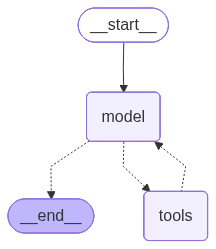

In [8]:
from IPython.display import Image, display
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent

# 시스템 프롬프트 (레퍼런스: FILE_USAGE_INSTRUCTIONS)
FILE_USAGE_INSTRUCTIONS = """You have access to a local file system to help you retain and save context. Today's date is {date}.

<Workflow Process>
1. **Orient**: Use ls() to see existing files before starting work
2. **Research**: Use web_search() to gather information - results are auto-saved to files
3. **Read**: Use read_file() to examine saved research results
4. **Synthesize**: Write your own analysis or summary files using write_file()
</Workflow Process>

<Context Offloading Strategy>
When handling large amounts of data:
- Web search results are automatically saved to files with summaries returned
- Read full content from files when you need details
- Keep only summaries and key findings in your working context
- Write final reports/analyses to files for user reference
</Context Offloading Strategy>

<Important Notes>
- Files are stored on actual local disk at: {workspace}
- Only access files within the workspace directory
- Use descriptive filenames that indicate content
</Important Notes>
""".format(date=get_today_str(), workspace=WORKSPACE_DIR.absolute())

# EXA 기반 웹 검색 도구 (컨텍스트 오프로딩 적용)
@tool(parse_docstring=True)
def web_search(query: str) -> str:
    """Search the web for information using EXA and save results to a file.
    
    This tool performs a semantic web search using EXA API, saves the full results
    to a local file for context offloading, and returns a concise summary.
    
    Args:
        query: The search query - be specific and clear about what you're looking for
    
    Returns:
        A summary of search results with the filename where full content is saved
    """
    try:
        # EXA 검색 수행
        results = exa_client.search_and_contents(
            query=query,
            num_results=5,
            text={"max_characters": 2000},
            highlights={"num_sentences": 3}
        )
        
        # 파일에 저장할 상세 내용 구성
        file_content = f"# Search Results: {query}\n"
        file_content += f"**Date:** {get_today_str()}\n"
        file_content += f"**Query:** {query}\n\n"
        file_content += "---\n\n"
        
        # 요약용 핵심 정보
        summary_points = []
        
        for i, result in enumerate(results.results, 1):
            file_content += f"## {i}. {result.title}\n"
            file_content += f"**URL:** {result.url}\n\n"
            
            if result.highlights:
                file_content += "### Key Highlights:\n"
                for highlight in result.highlights:
                    file_content += f"- {highlight}\n"
                summary_points.append(result.highlights[0][:100] if result.highlights else "")
            
            if result.text:
                file_content += f"\n### Full Text:\n{result.text}\n"
            
            file_content += "\n---\n\n"
        
        # 파일명 생성 및 저장
        safe_query = query.lower().replace(" ", "_")[:30]
        filename = f"search_{safe_query}_{get_today_str()}.md"
        target_file = WORKSPACE_DIR / filename
        target_file.write_text(file_content, encoding="utf-8")
        
        # 컨텍스트에 반환할 요약
        summary = f"""🔍 Search completed: "{query}"

📄 Full results saved to: {filename} ({target_file.stat().st_size} bytes)

📝 Key findings ({len(results.results)} results):
"""
        for i, result in enumerate(results.results[:3], 1):
            summary += f"{i}. **{result.title}**\n"
            if result.highlights:
                summary += f"   → {result.highlights[0][:150]}...\n"
        
        summary += f"\n💡 Use read_file('{filename}') to see full details."
        
        return summary
        
    except Exception as e:
        return f"Search error: {str(e)}"

# 모델 초기화
model = init_chat_model(model="openai:gpt-4o-mini", temperature=0.0)

# 도구 목록 (파일 도구 + 웹 검색)
tools = [ls, read_file, write_file, web_search]

# 에이전트 생성
agent = create_agent(
    model,
    tools,
    system_prompt=FILE_USAGE_INSTRUCTIONS,
    state_schema=AgentState,
)

print("✅ 에이전트가 생성되었습니다.")
print(f"📁 워크스페이스: {WORKSPACE_DIR.absolute()}")
print(f"🔍 EXA 웹 검색 도구 (컨텍스트 오프로딩 적용)")
print("\n📊 에이전트 그래프 구조:")
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))

## 5. 에이전트 실행

에이전트에게 리서치를 요청하고 파일에 저장하도록 합니다.

In [11]:
# 에이전트 실행 (스트리밍 모드)
print("🚀 에이전트 실행 시작 (스트리밍)")
print("=" * 60)

query = {
    "messages": [
        {
            "role": "user",
            "content": "Economic Order Quantity (EOQ) Model에 대해 검색하고, 핵심 내용을 요약해서 'EOQ_summary.md' 파일로 저장해줘.",
        }
    ],
}

# 스트리밍으로 실행 과정 확인
for chunk in agent.stream(query, stream_mode="updates"):
    for node_name, value in chunk.items():
        print(f"\n📍 [{node_name}] 노드 실행")
        
        if "messages" in value and value["messages"]:
            last_msg = value["messages"][-1]
            
            # Tool Call 표시
            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                for tc in last_msg.tool_calls:
                    print(f"   🔧 Tool: {tc['name']}")
                    if tc.get('args'):
                        args_preview = str(tc['args'])[:100]
                        print(f"   📝 Args: {args_preview}...")
            
            # 최종 응답 표시
            elif hasattr(last_msg, 'content') and last_msg.content:
                content = str(last_msg.content)
                if node_name == "agent" and not (hasattr(last_msg, 'tool_calls') and last_msg.tool_calls):
                    print(f"\n{'='*60}")
                    print("📝 에이전트 최종 응답:")
                    print("=" * 60)
                    print(content)

🚀 에이전트 실행 시작 (스트리밍)

📍 [model] 노드 실행
   🔧 Tool: web_search
   📝 Args: {'query': 'Economic Order Quantity (EOQ) Model'}...

📍 [tools] 노드 실행

📍 [model] 노드 실행
   🔧 Tool: write_file
   📝 Args: {'file_path': 'EOQ_summary.md', 'content': '# Economic Order Quantity (EOQ) Model Summary\n\n## Defi...

📍 [tools] 노드 실행

📍 [model] 노드 실행


## 6. 파일 시스템 상태 확인

In [12]:
# 🔍 실제 로컬 디스크에 저장된 파일 확인
print("📁 워크스페이스에 저장된 파일 목록:")
print("=" * 60)
print(f"디렉토리: {WORKSPACE_DIR.absolute()}")
print()

for item in sorted(WORKSPACE_DIR.iterdir()):
    if item.is_file():
        size = item.stat().st_size
        print(f"\n📄 {item.name} ({size} bytes)")
        print("-" * 40)
        # 내용 미리보기 (처음 500자)
        content = item.read_text(encoding="utf-8")
        preview = content[:500] + "..." if len(content) > 500 else content
        print(preview)

print("\n" + "=" * 60)
print("💡 파일 탐색기에서 직접 확인해보세요!")
print(f"   경로: {WORKSPACE_DIR.absolute()}")

📁 워크스페이스에 저장된 파일 목록:
디렉토리: c:\Users\shdnc\OneDrive\Desktop\UNIST\2026 생운관\File_maker_Project\agent_workspace


📄 EOQ_summary.md (1796 bytes)
----------------------------------------
# Economic Order Quantity (EOQ) Model Summary

## Definition
The Economic Order Quantity (EOQ) model is a fundamental inventory management tool that determines the optimal order quantity a company should purchase to minimize total inventory costs, which include ordering and holding costs.

## Key Components
1. **Demand Rate**: The rate at which inventory is used or sold over a specific period.
2. **Ordering Cost**: The fixed cost incurred every time an order is placed, regardless of the order si...

📄 search_economic_order_quantity_(eoq)__2026-05-05.md (21391 bytes)
----------------------------------------
# Search Results: Economic Order Quantity (EOQ) Model
**Date:** 2026-05-05
**Query:** Economic Order Quantity (EOQ) Model

---

## 1. EOQ Model | Springer Nature Link
**URL:** https://link.springer.com/ch